# 06 — Exposure Regression and Geometric Axis Decomposition

**Manuscript section:** Results §6 — *Geometric anomaly reflects training-exposure imbalance*

**Manuscript figures:** Supplementary Figure S4a–b

Tests whether geometric anomaly predicts perturbation sensitivity beyond what
expression frequency alone explains, using partial correlations and OLS regression.

**Data inputs:**
- `data/perturbation_sensitivity.csv`
- `data/gene_embedding_annotated.csv`

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', message='.*is_categorical_dtype.*')

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import statsmodels.api as sm

import glitch_style
importlib.reload(glitch_style)
from glitch_style import ACCENT_COLOR, CONTROL_COLOR, FIG_DOUBLE, FIG_SINGLE, GLITCH_COLOR, apply_style, save_fig

# ── Verify required inputs exist ──
from pathlib import Path
assert Path('data/perturbation_sensitivity.csv').exists(), "Missing data/perturbation_sensitivity.csv — run P06 first"

In [2]:
perturb = pd.read_csv('data/perturbation_sensitivity.csv')
annot = pd.read_csv('data/gene_embedding_annotated.csv')

merged = perturb.merge(annot, on='gene', how='inner', suffixes=('', '_annot'))
if 'log_max_tpm' not in merged.columns:
    merged['log_max_tpm'] = np.log1p(merged['max_tpm'])
if 'log_gene_length' not in merged.columns:
    merged['log_gene_length'] = np.log1p(merged['gene_length_bp'])

COVARIATES = ['log_max_tpm', 'expression_breadth', 'log_gene_length']
reg_df = merged.dropna(subset=['mean_shift'] + COVARIATES).copy()
print(f'Regression dataset: {len(reg_df)} genes ({(reg_df["group"]=="glitch").sum()} glitch, {(reg_df["group"]=="control").sum()} control)')

Regression dataset: 95 genes (50 glitch, 45 control)


## Fig S4a — Four-metric raw vs partial correlation decomposition

Norm        : raw ρ=+0.645, partial ρ=-0.010
Distance    : raw ρ=+0.726, partial ρ=+0.015
Cosine      : raw ρ=-0.864, partial ρ=-0.094
Isolation   : raw ρ=+0.858, partial ρ=+0.124
Composite   : raw ρ=+0.725, partial ρ=-0.019


Saved: figs/figS4a_metric_decomposition.pdf, figs/figS4a_metric_decomposition.png


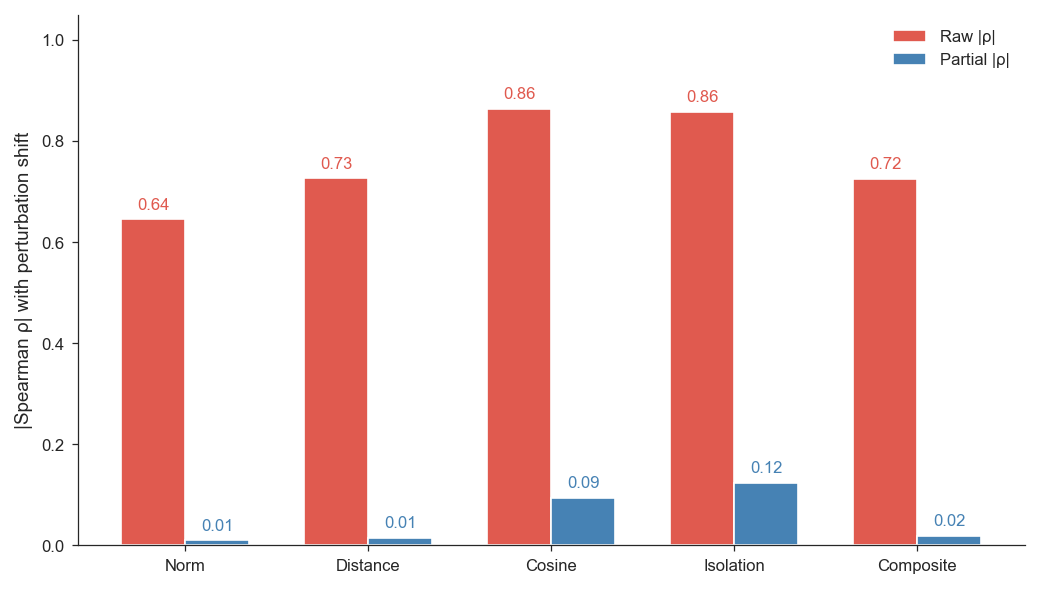

In [3]:
apply_style()

z_map = {
    'Norm': 'norm_zscore',
    'Distance': 'dist_zscore',
    'Cosine': 'cos_zscore',
    'Isolation': 'isolation_zscore',
    'Composite': 'anomaly_score',
}

results = []
for label, col in z_map.items():
    if col not in reg_df.columns:
        continue
    sub = reg_df.dropna(subset=[col])
    x = sub[col].astype(float)
    y = sub['mean_shift'].astype(float)
    X_cov = sm.add_constant(sub[COVARIATES].astype(float))

    rho_raw, _ = spearmanr(x, y)
    # Partial Spearman: OLS-residualize X and Y against covariates,
    # then Spearman-correlate the residuals (standard approach,
    # see e.g. Conover 1999; equivalent to rank-first for monotonic covariates)
    resid_x = sm.OLS(x, X_cov).fit().resid
    resid_y = sm.OLS(y, X_cov).fit().resid
    rho_part, _ = spearmanr(resid_x, resid_y)

    results.append({'metric': label, 'raw_rho': rho_raw, 'partial_rho': rho_part})
    print(f'{label:12s}: raw ρ={rho_raw:+.3f}, partial ρ={rho_part:+.3f}')

rc = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=FIG_DOUBLE, facecolor='white')
x_pos = np.arange(len(rc))
width = 0.35

ax.bar(x_pos - width/2, rc['raw_rho'].abs(), width, color=GLITCH_COLOR, label='Raw |ρ|', edgecolor='white')
ax.bar(x_pos + width/2, rc['partial_rho'].abs(), width, color=CONTROL_COLOR, label='Partial |ρ|', edgecolor='white')

for i, row in rc.iterrows():
    ax.text(i - width/2, abs(row['raw_rho']) + 0.02, f'{abs(row["raw_rho"]):.2f}',
            ha='center', fontsize=8, color=GLITCH_COLOR)
    ax.text(i + width/2, abs(row['partial_rho']) + 0.02, f'{abs(row["partial_rho"]):.2f}',
            ha='center', fontsize=8, color=CONTROL_COLOR)

ax.set_xticks(x_pos)
ax.set_xticklabels(rc['metric'])
ax.set_ylabel('|Spearman ρ| with perturbation shift')
ax.set_ylim(0, 1.05)
ax.legend()
sns.despine()
fig.tight_layout()
save_fig(fig, 'figS4a_metric_decomposition')
plt.show()

## Fig S4b — R² comparison

Expression only:  R² = 0.481
Anomaly only:     R² = 0.186
Combined:         R² = 0.485
ΔR² (adding anomaly to expression): 0.0043
Saved: figs/figS4b_r2_comparison.pdf, figs/figS4b_r2_comparison.png


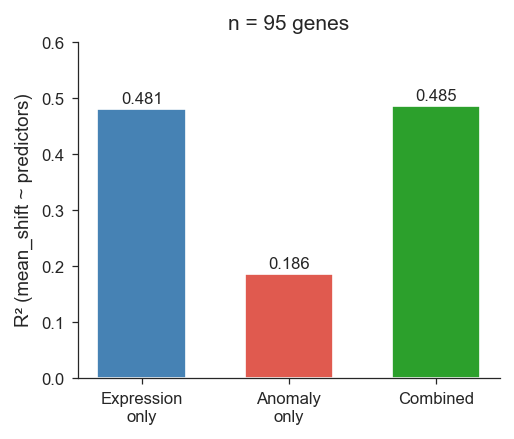

In [4]:
y = reg_df['mean_shift'].astype(float)
X_expr = sm.add_constant(reg_df[COVARIATES].astype(float))
X_full = sm.add_constant(reg_df[COVARIATES + ['anomaly_score']].astype(float))

r2_expr = sm.OLS(y, X_expr).fit().rsquared
r2_full = sm.OLS(y, X_full).fit().rsquared
r2_anom = sm.OLS(y, sm.add_constant(reg_df[['anomaly_score']].astype(float))).fit().rsquared

print(f'Expression only:  R² = {r2_expr:.3f}')
print(f'Anomaly only:     R² = {r2_anom:.3f}')
print(f'Combined:         R² = {r2_full:.3f}')
print(f'ΔR² (adding anomaly to expression): {r2_full - r2_expr:.4f}')

fig, ax = plt.subplots(figsize=FIG_SINGLE, facecolor='white')
bars = ax.bar(['Expression\nonly', 'Anomaly\nonly', 'Combined'],
              [r2_expr, r2_anom, r2_full],
              color=[CONTROL_COLOR, GLITCH_COLOR, ACCENT_COLOR],
              edgecolor='white', width=0.6)
for bar, val in zip(bars, [r2_expr, r2_anom, r2_full]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
            ha='center', fontsize=8)
ax.set_ylabel('R² (mean_shift ~ predictors)')
ax.set_ylim(0, 0.6)
ax.set_title(f'n = {len(reg_df)} genes')
sns.despine()
fig.tight_layout()
save_fig(fig, 'figS4b_r2_comparison')
plt.show()